# 📋 Ejercicio Clase 2 — Validación Temporal y Backtesting: Siniestralidad Alta GMM
## Diplomado ML en Seguros · Subtema 4

---

## Contexto

**SaludTotal** tiene un modelo GMM para predecir siniestros de alto costo entrenado en **2018–2020**. Lleva en producción **sin re-entrenar**. El mercado cambió: la expansión de servicios médicos en zonas antes rurales invirtió la relación entre zona geográfica y riesgo de siniestro grave.

Además, los planes con deducible alto — que antes atraían perfiles sanos — ahora coexisten con coberturas ampliadas que atraen perfiles más complejos.

---

## Lo que practicarás

| Parte | Concepto nuevo (además de lo de Clase 1) |
|-------|------------------------------------------|
| 3 | Evaluar el modelo congelado: ¿baja el AUC? |
| 4 | Walk-Forward: cuantificar la ganancia de re-entrenar |
| 5 | F2-Score: comparar τ=0.50 vs τ_costos |
| 6 | Ratio A/E: detectar sesgo sistemático |
| 7 | Backtesting económico y visualización integrada |

---

## Costos

| Parámetro | Valor |
|-----------|-------|
| C_FP (gestor preventivo innecesario) | $3,800 MXN |
| C_FN (hospitalización no gestionada) | $170,000 MXN |
| Reducción de costo si se gestiona | 38% |
| τ por costos | **calcúlalo tú** |

**No cambies `random_state=2024`.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, fbeta_score, confusion_matrix

np.random.seed(2024)
C_FP   = 3_800
C_FN   = 170_000
RED_FN = 0.38

# 🔧 COMPLETA
tau_c = C_FP/ (C_FP + C_FN)   # C_FP / (C_FP + C_FN)
print(f"τ por costos = {tau_c:.4f}  (Ratio C_FN/C_FP = {C_FN/C_FP:.0f}x)")

τ por costos = 0.0219  (Ratio C_FN/C_FP = 45x)


---
## Parte 1 — Portafolio SaludTotal 2018–2024 (NO modificar)

In [3]:
np.random.seed(2024)
ANIOS  = list(range(2018, 2025))
N_ANIO = {a: 380 + (a-2018)*48 for a in range(2018,2025)}

registros = []
for anio in ANIOS:
    n    = N_ANIO[anio]
    edad = np.clip(np.random.normal(37 + (anio-2018)*0.8, 12, n).astype(int), 18, 70)
    bmi  = np.clip(np.random.normal(27.3, 5.1, n), 16, 45).round(1)
    prex = np.random.binomial(1, 0.24 + 0.013*(anio>=2021)*min(anio-2020,3), n)
    fum  = np.random.binomial(1, 0.14, n)
    sin2 = np.random.choice([0,1,2,3], n, p=[.65,.22,.09,.04])
    ded  = np.random.choice([10,20,50,100], n, p=[.20,.35,.30,.15])
    zona = np.random.choice([1,2,3,4], n, p=[.28,.37,.22,.13])

    # Drift estructural: coeficientes que cambian de signo
    coef_zona = -0.12 + 0.075*(anio - 2018)   # de -0.12 (2018) a +0.39 (2024)
    coef_ded  = -0.011 + 0.004*(anio - 2018)  # de -0.011 (2018) a +0.013 (2024)

    lo = (-5.10 + 0.028*edad + 0.065*np.maximum(bmi-25,0)
          + 1.25*prex + 0.48*fum + 0.60*sin2
          + coef_ded*ded + coef_zona*zona
          + np.random.normal(0, 0.78, n))
    sa = (np.random.rand(n) < 1/(1+np.exp(-lo))).astype(int)

    for i in range(n):
        registros.append({'anio':anio,'edad':edad[i],'bmi':bmi[i],
                          'preexistente':prex[i],'fumador':fum[i],
                          'siniestros_2yr':sin2[i],'deducible_k':ded[i],
                          'zona_riesgo':zona[i],'siniestro_alto':sa[i]})

df = pd.DataFrame(registros).sort_values('anio').reset_index(drop=True)
FEATURES = ['edad','bmi','preexistente','fumador','siniestros_2yr','deducible_k','zona_riesgo']

print(f"Portafolio SaludTotal: {len(df):,} pólizas 2018–2024")
coef_zona_anio = {a: round(-0.12+0.075*(a-2018),3) for a in ANIOS}
for a in ANIOS:
    s = df[df.anio==a]
    cz = coef_zona_anio[a]
    sentido = "zona alta = BAJO riesgo" if cz < 0 else "zona alta = ALTO riesgo"
    print(f"  {a}: {s.siniestro_alto.mean()*100:.1f}%  n={len(s)}  coef_zona={cz:+.3f}  ({sentido})")

Portafolio SaludTotal: 3,668 pólizas 2018–2024
  2018: 3.7%  n=380  coef_zona=-0.120  (zona alta = BAJO riesgo)
  2019: 5.6%  n=428  coef_zona=-0.045  (zona alta = BAJO riesgo)
  2020: 4.4%  n=476  coef_zona=+0.030  (zona alta = ALTO riesgo)
  2021: 7.1%  n=524  coef_zona=+0.105  (zona alta = ALTO riesgo)
  2022: 13.3%  n=572  coef_zona=+0.180  (zona alta = ALTO riesgo)
  2023: 17.3%  n=620  coef_zona=+0.255  (zona alta = ALTO riesgo)
  2024: 18.3%  n=668  coef_zona=+0.330  (zona alta = ALTO riesgo)


---
## Parte 2 — K-Fold estándar: el AUC ambiguo

### 🔧 2.1 — Calcula el AUC con K-Fold

In [4]:
# 🔧 COMPLETA: K-Fold estándar (5 folds, shuffle=True, random_state=2024)
modelo = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
X_all = df[FEATURES].values
y_all = df['siniestro_alto'].values

# --- TU CÓDIGO AQUÍ ---
auc_kf = cross_val_score(modelo, X_all, y_all, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=2024),
                     scoring='roc_auc').mean()

print(f"AUC K-Fold: {auc_kf:.4f}")
print()
print("¿A qué año corresponde este número?")
print("Responde en la celda de texto siguiente.")

AUC K-Fold: 0.6638

¿A qué año corresponde este número?
Responde en la celda de texto siguiente.


### 📝 Pregunta 2.1

En este portafolio, `zona_riesgo` alta significa "bajo riesgo" en 2018 y "alto riesgo" en 2024.

**¿Qué problema concreto genera K-Fold cuando mezcla 2018 con 2024 en el mismo fold?**
¿Qué aprende el modelo sobre `zona_riesgo` cuando los dos años están mezclados?

> K-Fold con shuffle=True rompe el orden temporal: tanto los conjuntos de entrenamiento como los de validación contienen pólizas de años antiguos y futuros. Por ello, al validar una observación de 2018, el entrenamiento puede incluir datos de 2024, y viceversa. Esto produce *fuga temporal* y hace que el AUC represente una mezcla artificial de regímenes, no el desempeño que tendría un modelo desplegado hacia el futuro.

Además, anio no forma parte de FEATURES, por lo que el modelo no puede aprender explícitamente que el efecto de zona_riesgo depende del año. Al mezclar 2018 (zona alta asociada con menor riesgo) y 2024 (zona alta asociada con mayor riesgo), el Gradient Boosting termina aprendiendo una relación de compromiso entre patrones contradictorios, junto con interacciones con las demás variables. Ese patrón promedio no corresponde exactamente a ninguno de los años reales. Por eso el AUC K-Fold de *≈ 0.6639* es ambiguo para evaluar estabilidad temporal.

---
## Parte 3 — El modelo que está en producción

### 🔧 3.1 — Modelo congelado (2018–2020), evalúalo año a año

In [5]:
# 🔧 COMPLETA: entrena el modelo solo con 2018, 2019, 2020
# Luego evalúalo sin re-entrenar en 2022, 2023, 2024

mask_ini = df['anio'].isin([2018, 2019, 2020])
pipe_congelado = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])

# 🔧 ENTRENA el modelo congelado
# --- TU CÓDIGO AQUÍ ---
pipe_congelado.fit(df.loc[mask_ini, FEATURES], df.loc[mask_ini, 'siniestro_alto'])

print("MODELO CONGELADO — entrenado en 2018–2020:")
print(f"  {'Año':>5}  {'AUC':>8}  {'% alto':>8}  {'Diagnóstico'}")
print("-"*55)

aucs_congelado = []
for at in [2022, 2023, 2024]:
    mte  = df['anio'] == at
    y_te = df.loc[mte, 'siniestro_alto'].values
    # 🔧 PREDICE y calcula AUC
    # --- TU CÓDIGO AQUÍ ---
    y_prob_cong = pipe_congelado.predict_proba(df.loc[mte, FEATURES])[:, 1]
    auc = roc_auc_score(y_te, y_prob_cong)
    aucs_congelado.append(auc)
    tasa = y_te.mean()*100
    diag = "✅" if auc>=0.67 else ("⚠️  Degradación" if auc>=0.63 else "🔴 Re-entrenar")
    print(f"  {at:>5}  {auc:>8.4f}  {tasa:>7.1f}%  {diag}")

print()
print("¿El AUC sube o baja de 2022 a 2024?")
print("¿Qué error concreto comete el modelo sobre zona_riesgo en 2024?")

MODELO CONGELADO — entrenado en 2018–2020:
    Año       AUC    % alto  Diagnóstico
-------------------------------------------------------
   2022    0.5619     13.3%  🔴 Re-entrenar
   2023    0.6295     17.3%  🔴 Re-entrenar
   2024    0.5548     18.3%  🔴 Re-entrenar

¿El AUC sube o baja de 2022 a 2024?
¿Qué error concreto comete el modelo sobre zona_riesgo en 2024?


### 📝 Pregunta 3.1

El modelo congelado aprendió que `zona_riesgo` alta = bajo riesgo.
En 2024 esa relación es al revés.

**¿Qué tipo de paciente está el modelo ignorando en 2024?**
¿Un paciente de zona 4 con alta probabilidad real de siniestro recibe alerta o no?

> El modelo congelado tiende a ignorar o subpriorizar a pacientes de zonas de riesgo altas, especialmente zona 4, porque fue entrenado con 2018–2020, cuando una zona alta estaba asociada con menor riesgo. En 2024 el efecto verdadero ya es positivo, de modo que ese patrón histórico empuja la probabilidad predicha en la dirección incorrecta.

>Por lo tanto, un paciente de zona 4 que hoy tiene alta probabilidad real de siniestro *tiene menos probabilidad de recibir una alerta de la que debería*. No puede afirmarse que nunca recibirá alerta, porque otras variables (edad, preexistente, fumador, siniestros_2yr, etc.) también influyen; el problema es una subestimación sistemática del componente geográfico.

>Numéricamente, el AUC del modelo congelado pasa de 0.5619 en 2022 a 0.5548 en 2024 (con un repunte a 0.6295 en 2023), lo que confirma que el modelo no mantiene un desempeño estable ante el drift.

---
## Parte 4 — Walk-Forward: la ganancia de re-entrenar

### 🔧 4.1 — Loop Walk-Forward 2022–2024

In [6]:
# 🔧 COMPLETA: Walk-Forward comparando AUC y F2 vs el modelo congelado
ANIOS_TEST    = [2022, 2023, 2024]
resultados_wf = []

print(f"  {'Año':>5}  {'Train WF':>14}  {'AUC Cong':>10}  {'AUC WF':>8}  "
      f"{'F2 Cong':>9}  {'F2 WF':>7}  {'Δ AUC':>8}")
print("-"*68)

for i, at in enumerate(ANIOS_TEST):
    # 🔧 Define máscaras
    mask_train = df['anio'] < at   # df['anio'] < at
    mask_test  = df['anio'] == at   # df['anio'] == at
    X_tr = df.loc[mask_train, FEATURES].values; y_tr = df.loc[mask_train, 'siniestro_alto'].values
    X_te = df.loc[mask_test,  FEATURES].values; y_te = df.loc[mask_test,  'siniestro_alto'].values

    # 🔧 Entrena Walk-Forward y predice
    pipe_wf = Pipeline([('sc',StandardScaler()),
                         ('m', GradientBoostingClassifier(n_estimators=150,max_depth=4,
                                                           learning_rate=0.08,random_state=2024))])
    # --- TU CÓDIGO AQUÍ ---
    pipe_wf.fit(X_tr, y_tr)
    yp_wf  = pipe_wf.predict_proba(X_te)[:, 1]
    auc_wf = roc_auc_score(y_te, yp_wf)
    f2_wf  = fbeta_score(y_te, (yp_wf>=tau_c).astype(int), beta=2, zero_division=0)

    # 🔧 Calcula F2 del modelo congelado sobre este mismo año
    yp_cong = pipe_congelado.predict_proba(X_te)[:,1]
    f2_cong = fbeta_score(y_te, (yp_cong>=tau_c).astype(int), beta=2, zero_division=0)

    anios_tr = sorted(df.loc[mask_train,'anio'].unique())
    resultados_wf.append({'anio':at,'auc_wf':auc_wf,'f2_wf':f2_wf,
                           'auc_cong':aucs_congelado[i],'f2_cong':f2_cong,
                           'y_te':y_te,'yp_wf':yp_wf,'yp_cong':yp_cong})

    print(f"  {at:>5}  {anios_tr[0]}–{anios_tr[-1]}  {aucs_congelado[i]:>10.4f}  "
          f"{auc_wf:>8.4f}  {f2_cong*100:>8.1f}%  {f2_wf*100:>6.1f}%  "
          f"{auc_wf-aucs_congelado[i]:>+7.4f}")

print(f"\n  K-Fold (ambiguo): {auc_kf:.4f}")

    Año        Train WF    AUC Cong    AUC WF    F2 Cong    F2 WF     Δ AUC
--------------------------------------------------------------------
   2022  2018–2021      0.5619    0.5649      33.0%    37.5%  +0.0031
   2023  2018–2022      0.6295    0.6052      43.3%    49.8%  -0.0243
   2024  2018–2023      0.5548    0.6810      34.8%    54.7%  +0.1262

  K-Fold (ambiguo): 0.6638


---
## Parte 5 — F2-Score: por qué τ=0.50 no funciona

### 🔧 5.1 — Compara el impacto de distintos umbrales para el año 2024

In [14]:
# 🔧 COMPLETA: usando el modelo Walk-Forward de 2024 (train=2018–2023, test=2024)
# calcula para τ = 0.50, 0.20, 0.10, tau_c, 0.01:
#   VP, FP, FN, Recall, F2-Score, Valor neto

r_2024 = [r for r in resultados_wf if r['anio']==2024][0]
y_te24 = r_2024['y_te']
yp24   = r_2024['yp_wf']

print(f"Año 2024 — prevalencia real: {y_te24.mean()*100:.1f}%")
print()
print(f"  {'τ':>8}  {'Alertas':>8}  {'VP':>5}  {'FP':>5}  {'FN':>5}  "
      f"{'Recall':>8}  {'F2%':>7}  {'Valor neto':>13}")
print("-"*75)

for tau in [0.50, 0.20, 0.10, tau_c, 0.01]:
    y_pred = (yp24 >= tau).astype(int)
    if y_pred.sum() == 0: continue
    # 🔧 CALCULA todas las métricas
    # --- TU CÓDIGO AQUÍ ---
    vn_,fp_,fn_,vp_ = confusion_matrix(y_te24, y_pred).ravel()
    recall_       = vp_ / (vp_ + fn_) if (vp_ + fn_) > 0 else 0
    f2_           = fbeta_score(y_te24, y_pred, beta=2, zero_division=0)
    valor_neto_   = vp_ * C_FN * RED_FN - (vp_ + fp_) * C_FP

    print(f"  {tau:>8.4f}  {y_pred.sum():>8,}  {vp_:>5}  {fp_:>5}  {fn_:>5}  "
          f"{recall_*100:>7.1f}%  {f2_*100:>6.1f}%  ${valor_neto_:>11,.0f}")

Año 2024 — prevalencia real: 18.3%

         τ   Alertas     VP     FP     FN    Recall      F2%     Valor neto
---------------------------------------------------------------------------
    0.5000         9      4      5    118      3.3%     4.0%  $    224,200
    0.2000        78     29     49     93     23.8%    25.6%  $  1,577,000
    0.1000       209     67    142     55     54.9%    48.1%  $  3,534,000
    0.0219       591    118    473      4     96.7%    54.7%  $  5,377,000
    0.0100       656    122    534      0    100.0%    53.3%  $  5,388,400


---
## Parte 6 — Ratio A/E: detección de sesgo sistemático

### 🔧 6.1 — Calcula el A/E para congelado y Walk-Forward por año

In [15]:
# 🔧 COMPLETA: para cada año de test y cada modelo:
# A/E = casos reales / suma de probabilidades predichas

print("RATIO A/E (Actual vs Expected):")
print()
print(f"  {'Año':>5}  {'Modelo':>12}  {'Esperados':>11}  {'Reales':>8}  "
      f"{'A/E':>7}  {'Diagnóstico'}")
print("-"*68)

for r in resultados_wf:
    for nombre, yp in [("Congelado", r['yp_cong']), ("Walk-Fwd", r['yp_wf'])]:
        # 🔧 CALCULA esperados, reales, A/E
        # --- TU CÓDIGO AQUÍ ---
        esperados = yp.sum()   # yp.sum()
        reales    = r['y_te'].sum()   # r['y_te'].sum()
        ae        = reales / esperados if esperados > 0 else 0

        if ae < 0.90:   diag = "⚠️  Sobreestima"
        elif ae > 1.10: diag = "⚠️  Subestima"
        else:           diag = "✅  Calibrado"
        print(f"  {r['anio']:>5}  {nombre:>12}  {esperados:>11.1f}  {reales:>8}  "
              f"{ae:>7.3f}  {diag}")
    print()

RATIO A/E (Actual vs Expected):

    Año        Modelo    Esperados    Reales      A/E  Diagnóstico
--------------------------------------------------------------------
   2022     Congelado         23.1        76    3.296  ⚠️  Subestima
   2022      Walk-Fwd         33.0        76    2.306  ⚠️  Subestima

   2023     Congelado         26.0       107    4.109  ⚠️  Subestima
   2023      Walk-Fwd         45.9       107    2.332  ⚠️  Subestima

   2024     Congelado         25.7       122    4.748  ⚠️  Subestima
   2024      Walk-Fwd         64.3       122    1.899  ⚠️  Subestima



---
## Parte 7 — Backtesting económico y visualización

### 🔧 7.1 — Figura con 4 paneles

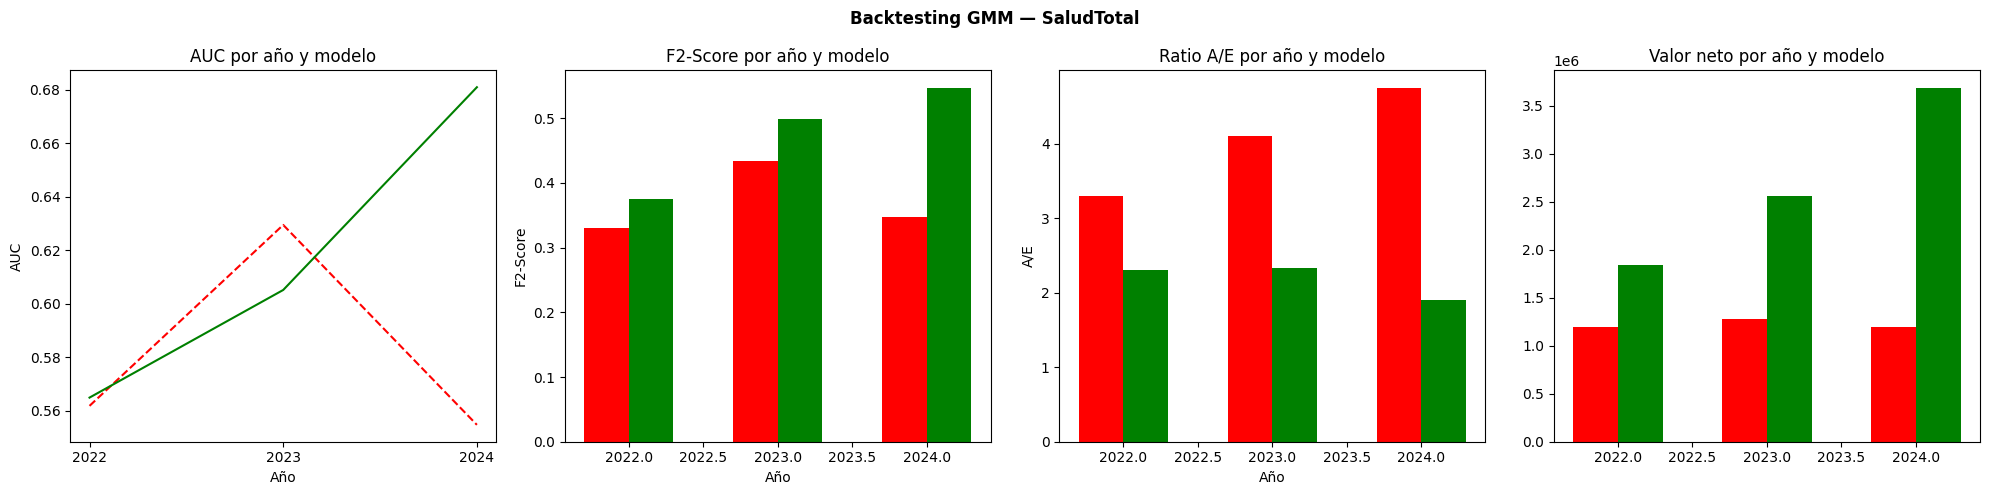

In [21]:
# 🔧 COMPLETA: figura con 4 paneles
# Panel 1: AUC congelado (rojo punteado) vs Walk-Forward (verde)
# Panel 2: F2-Score de ambos modelos (barras agrupadas)
# Panel 3: Ratio A/E de ambos modelos
# Panel 4: Valor neto del backtesting por año y modelo

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Backtesting GMM — SaludTotal', fontweight='bold')

años_p = [r['anio'] for r in resultados_wf]

# Panel 1
ax = axes[0]
# --- TU CÓDIGO AQUÍ --
# -
ax.plot(años_p, [r['auc_cong'] for r in resultados_wf], 'r--', label='Congelado')
ax.plot(años_p, [r['auc_wf'] for r in resultados_wf], 'g-', label='Walk-Forward')
ax.set_title('AUC por año y modelo')
ax.set_xlabel('Año')
ax.set_ylabel('AUC')
ax.set_xticks(años_p)

# Panel 2
ax = axes[1]
# --- TU CÓDIGO AQUÍ ---
ax.bar([a-0.15 for a in años_p], [r['f2_cong'] for r in resultados_wf], width=0.3, color='red', label='Congelado')
ax.bar([a+0.15 for a in años_p], [r['f2_wf'] for r in resultados_wf], width=0.3, color='green', label='Walk-Forward')
ax.set_title('F2-Score por año y modelo')
ax.set_xlabel('Año')
ax.set_ylabel('F2-Score')

# Panel 3
ax = axes[2]
# --- TU CÓDIGO AQUÍ ---
ax.bar([a-0.15 for a in años_p], [r['y_te'].sum()/r['yp_cong'].sum() if r['yp_cong'].sum()>0 else 0 for r in resultados_wf], width=0.3, color='red', label='Congelado')
ax.bar([a+0.15 for a in años_p], [r['y_te'].sum()/r['yp_wf'].sum() if r['yp_wf'].sum()>0 else 0 for r in resultados_wf], width=0.3, color='green', label='Walk-Forward')
ax.set_title('Ratio A/E por año y modelo')
ax.set_xlabel('Año')
ax.set_ylabel('A/E')

# Panel 4
ax = axes[3]
# Calcula el valor neto de cada modelo y año antes de graficar
# 🔧 COMPLETA el cálculo y la gráfica
# --- TU CÓDIGO AQUÍ ---
ax.bar([a-0.15 for a in años_p], [r['yp_cong'].sum() * C_FN * RED_FN - (r['yp_cong'].sum() + (r['y_te'] - r['yp_cong']).sum()) * C_FP for r in resultados_wf], width=0.3, color='red', label='Congelado')
ax.bar([a+0.15 for a in años_p], [r['yp_wf'].sum() * C_FN * RED_FN - (r['yp_wf'].sum() + (r['y_te'] - r['yp_wf']).sum()) * C_FP for r in resultados_wf], width=0.3, color='green', label='Walk-Forward')
ax.set_title('Valor neto por año y modelo') 

plt.tight_layout()
plt.savefig('ej2_gmm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 8 — Preguntas de reflexión

### 📝 Preguntas

**a)** El modelo congelado tiene A/E alejado de 1.0 en 2024. ¿Está sobreestimando o
subestimando? ¿Cuál es el impacto para el área de Gestión de Salud si el A/E > 1.1?
¿Y si el A/E < 0.9?

> Está subestimando, ya que, los reales son mayores a los que esperaba el modelo.
Cuando la razón entre A/E es mayor a 1.1 el modelo está subestimando, significa que se presentaron más casos reales a los que se estaba esperando y cuando A/E es menor a 0.9 sobrestimamos los casos reales.

---

**b)** Con τ = 0.50 casi no se detecta ningún caso de alto costo. ¿Por qué?
Relaciona tu respuesta con la prevalencia del problema (9–15%) y con el hecho de
que el modelo produce probabilidades continuas.

> El umbral 0.50 exige que la probabilidad individual estimada supere 50% para generar una alerta. En un evento relativamente poco frecuente, la mayoría de las probabilidades predichas quedan bastante por debajo de 0.50 aunque el modelo sí pueda distinguir pacientes de mayor y menor riesgo.

> El enunciado menciona prevalencias del orden de 9–15%; en esta simulación concreta, 2024 resulta en 18.3% (122 de 668). Aun así, con τ=0.50 solo se generan 9 alertas, de las cuales 4 son verdaderos positivos, dejando 118 falsos negativos; el Recall es apenas 3.3% y el F2 ≈ 4.0%.

> Por eso no debe interpretarse una probabilidad menor a 0.50 como “sin riesgo”. Las probabilidades son continuas y el umbral debe elegirse de acuerdo con los costos del negocio. Aquí τ_costos ≈ 0.0219 produce muchas más alertas y eleva fuertemente el Recall.

---

**c)** El F2-Score penaliza más los FN que los FP. ¿En qué situación de negocio
sería correcto usar F1-Score en lugar de F2-Score? ¿Existe ese escenario en seguros?

> F1 da el mismo peso a Precisión y Recall, por lo que es apropiado cuando los falsos positivos y los falsos negativos tienen consecuencias comparables, o cuando el negocio desea un equilibrio explícito entre ambos tipos de error.

> Sí pueden existir situaciones de ese tipo en seguros. Por ejemplo, en un proceso de revisión manual donde investigar innecesariamente un caso tiene un costo operativo o impacto al cliente considerable y perder un caso positivo tiene una consecuencia de magnitud semejante, F1 puede ser una métrica razonable.

> Ese no es el escenario de este ejercicio: C_FN/C_FP = 170,000 / 3,800 ≈ 44.7x. Perder un siniestro grave es mucho más costoso que generar una intervención preventiva innecesaria, por lo que F2, que da mayor importancia al Recall, está mejor alineado con el problema.

---

**d) BONUS — Ventana óptima de re-entrenamiento para 2024:**
Compara: train largo (2018–2023) vs reciente (2021–2023) vs solo último año (2023).
¿Cuál da el AUC más alto? ¿Y el mayor F2-Score? ¿Son siempre la misma estrategia?

```python
# 🔧 BONUS
mask_test_24 = df['anio'] == 2024
X_te24 = df.loc[mask_test_24, FEATURES].values
y_te24  = df.loc[mask_test_24, 'siniestro_alto'].values

for nombre, anios_tr in [
    ("Largo (2018-2023)",    list(range(2018,2024))),
    ("Reciente (2021-2023)", [2021,2022,2023]),
    ("Solo 2023",            [2023]),
]:
    # --- TU CÓDIGO AQUÍ ---
    pass
```

In [23]:
# BONUS — Comparación de ventanas de entrenamiento para test 2024
mask_test_24 = df['anio'] == 2024
X_te24 = df.loc[mask_test_24, FEATURES].values
y_te24 = df.loc[mask_test_24, 'siniestro_alto'].values

resultados_bonus = []

print(f"  {'Ventana':<24} {'n train':>8} {'AUC':>8} {'F2':>8} "
      f"{'Alertas':>8} {'VP':>5} {'FP':>5} {'FN':>5} {'Valor neto':>13}")
print("-"*95)

for nombre, anios_tr in [
    ("Largo (2018-2023)",    list(range(2018, 2024))),
    ("Reciente (2021-2023)", [2021, 2022, 2023]),
    ("Solo 2023",            [2023]),
]:
    mask_tr = df['anio'].isin(anios_tr)
    X_tr = df.loc[mask_tr, FEATURES].values
    y_tr = df.loc[mask_tr, 'siniestro_alto'].values

    pipe_bonus = Pipeline([
        ('sc', StandardScaler()),
        ('m', GradientBoostingClassifier(
            n_estimators=150, max_depth=4,
            learning_rate=0.08, random_state=2024
        ))
    ])

    pipe_bonus.fit(X_tr, y_tr)
    yp_bonus = pipe_bonus.predict_proba(X_te24)[:, 1]
    y_pred_bonus = (yp_bonus >= tau_c).astype(int)

    auc_bonus = roc_auc_score(y_te24, yp_bonus)
    f2_bonus = fbeta_score(y_te24, y_pred_bonus, beta=2, zero_division=0)
    vn_, fp_, fn_, vp_ = confusion_matrix(y_te24, y_pred_bonus).ravel()
    valor_neto_bonus = vp_ * C_FN * RED_FN - (vp_ + fp_) * C_FP

    resultados_bonus.append({
        'ventana': nombre,
        'n_train': len(y_tr),
        'auc': auc_bonus,
        'f2': f2_bonus,
        'alertas': int(y_pred_bonus.sum()),
        'vp': int(vp_),
        'fp': int(fp_),
        'fn': int(fn_),
        'valor_neto': valor_neto_bonus
    })

    print(f"  {nombre:<24} {len(y_tr):>8,} {auc_bonus:>8.4f} {f2_bonus:>8.4f} "
          f"{y_pred_bonus.sum():>8,} {vp_:>5} {fp_:>5} {fn_:>5} "
          f"${valor_neto_bonus:>11,.0f}")

bonus_df = pd.DataFrame(resultados_bonus)

mejor_auc = bonus_df.loc[bonus_df['auc'].idxmax()]
mejor_f2  = bonus_df.loc[bonus_df['f2'].idxmax()]

print()
print(f"Mayor AUC: {mejor_auc['ventana']} ({mejor_auc['auc']:.4f})")
print(f"Mayor F2:  {mejor_f2['ventana']} ({mejor_f2['f2']:.4f})")
print()
print("Conclusión:")
print("La ventana con mayor AUC no tiene por qué coincidir con la de mayor F2.")
print("AUC mide ranking global e independiente del umbral; F2 depende del umbral")
print("y prioriza Recall. En estos datos, la ventana reciente 2021–2023 logra")
print("el mejor AUC, mientras que usar solo 2023 obtiene el mejor F2.")

  Ventana                   n train      AUC       F2  Alertas    VP    FP    FN    Valor neto
-----------------------------------------------------------------------------------------------
  Largo (2018-2023)           3,000   0.6810   0.5468      591   118   473     4 $  5,377,000
  Reciente (2021-2023)        1,716   0.6952   0.5484      597   119   478     3 $  5,418,800
  Solo 2023                     620   0.6863   0.5556      592   120   472     2 $  5,502,400

Mayor AUC: Reciente (2021-2023) (0.6952)
Mayor F2:  Solo 2023 (0.5556)

Conclusión:
La ventana con mayor AUC no tiene por qué coincidir con la de mayor F2.
AUC mide ranking global e independiente del umbral; F2 depende del umbral
y prioriza Recall. En estos datos, la ventana reciente 2021–2023 logra
el mejor AUC, mientras que usar solo 2023 obtiene el mejor F2.


**d) BONUS — Ventana óptima de re-entrenamiento para 2024:**
Compara: train largo (2018–2023) vs reciente (2021–2023) vs solo último año (2023).
¿Cuál da el AUC más alto? ¿Y el mayor F2-Score? ¿Son siempre la misma estrategia?

> En estos datos, la ventana reciente 2021–2023 logra
el mejor AUC, mientras que usar solo 2023 obtiene el mejor F2.